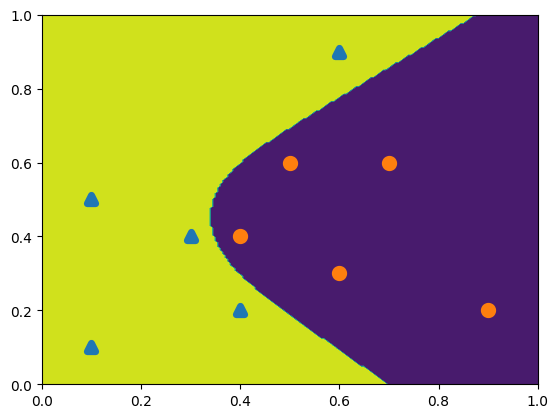

In [ ]:
import numpy as np
from numpy.random import uniform, randint, randn, normal
import sys
from timeit import default_timer as dt
def activate(x, W, b):
    '''
    Inputs:

    Outputs:

    Description: Sigmoid activation function
    '''
    return 1 / (1 + np.exp(-(np.dot(W, x) + b)))

def cost_function(W2,W3,W4,b2,b3,b4, x1, x2,y):

    '''
    Inputs:

    Outputs:

    Description:
    '''

    costvec = np.zeros((10, 1))
    x       = np.zeros((2,  1))
    for i in np.arange(costvec.shape[0]):
        x[0,0], x[1,0] = x1[i], x2[i]
        a2 = activate(x,  W2, b2)
        a3 = activate(a2, W3, b3)
        a4 = activate(a3, W4, b4)
        costvec[i] = np.linalg.norm(a4.ravel()-y[:,i], 2)

    return np.linalg.norm(costvec, 2)**2

def predict(W2, W3, W4, b2, b3, b4, xvec):

    a2 = activate(xvec, W2, b2)
    a3 = activate(a2,   W3, b3)
    a4 = activate(a3,   W4, b4)

    return a4

import matplotlib.pylab as plt

x1 = np.array([0.1, 0.3, 0.1, 0.6, 0.4, 0.6, 0.5, 0.9, 0.4, 0.7])
x2 = np.array([0.1, 0.4, 0.5, 0.9, 0.2, 0.3, 0.6, 0.2, 0.4, 0.6])

y           = np.zeros((2, 10))
y[0:1, 0:5] = np.ones((1,  5))
y[0:1, 5: ] = np.zeros((1, 5))
y[0:1, 5: ] = np.zeros((1, 5))
y[1: , 5: ] = np.ones((1,  5))

W2,W3,W4 = normal(size=(2,2)), normal(size=(3,2)), normal(size=(2, 3))
b2,b3,b4 = normal(size=(2,1)), normal(size=(3,1)), normal(size=(2, 1))

eta = 0.75
Niter = 100000


xvec = np.zeros((2,1))
yvec = np.zeros((2,1))
cost_value = np.zeros((Niter,1))
for counter in np.arange(Niter):
    k = randint(10)
    xvec[0,0], xvec[1,0] = x1[k], x2[k]
    yvec[:,0] = y[:, k]

    # forward pass
    a2 = activate(xvec, W2, b2)
    a3 = activate(a2,   W3, b3)
    a4 = activate(a3,   W4, b4)

    # backward pass
    delta4 = a4 * (1 - a4) * (a4 - yvec)

    delta3 = a3 * (1 - a3) * np.dot(W4.T, delta4)

    delta2 = a2 * (1 - a2) * np.dot(W3.T, delta3)

    W2 -= eta * delta2 * xvec.T
    W3 -= eta * delta3 * a2.T
    W4 -= eta * delta4 * a3.T

    b2 -= eta * delta2
    b3 -= eta * delta3
    b4 -= eta * delta4

    cost_value[counter] = cost_function(W2,W3,W4,b2,b3,b4,x1, x2, y)

#plt.plot(cost_value)
#plt.show()

X, Y = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))

X1Test = np.array(X.ravel())
X2Test = np.array(Y.ravel())

XTest  = np.stack((X1Test, X2Test), axis = 1)
empty  = np.zeros(200*200)


for i in np.arange(XTest.shape[0]):

    xvec[0,0], xvec[1,0] = XTest[i, 0], XTest[i, 1]


    YPredictions = predict(W2, W3, W4, b2, b3, b4, xvec)
    YPredictions = np.array(YPredictions[0] >= YPredictions[1])


    if YPredictions[0] == True:
        empty[i] = 1


YPred = empty.reshape((200, 200))
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(YPred)
plt.contourf(X, Y, YPred)

plt.scatter(x1[0:5], x2[0:5], marker='^', lw=5)
plt.scatter(x1[5:],  x2[5:], marker='o', lw=5)
plt.show()

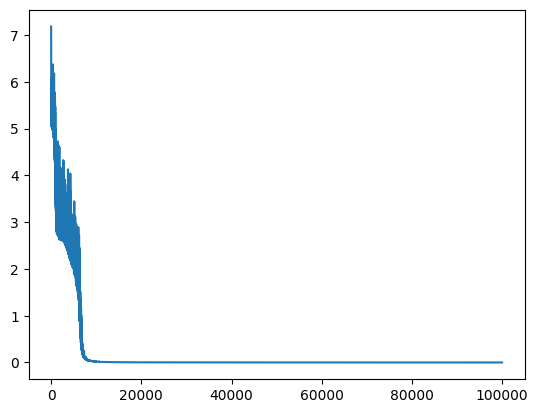

In [ ]:
plt.plot(cost_value)
plt.show()

Training accuracy: 90.0%


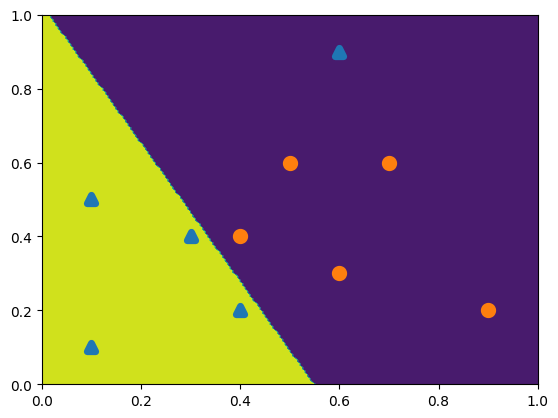

In [ ]:
import numpy as np
from numpy.random import randint, normal
import matplotlib.pylab as plt


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def activate(x, W, b):
    """a = σ(Wx + b)"""
    return sigmoid(W @ x + b)

def predict_proba(W2, W3, W4, b2, b3, b4, xvec):
    """Forward pass returning 2-dim output (class scores in [0,1])"""
    a2 = activate(xvec, W2, b2)
    a3 = activate(a2,   W3, b3)
    a4 = activate(a3,   W4, b4)
    return a4

def predict_label(W2, W3, W4, b2, b3, b4, xvec):
    """Class 0 if a4[0] >= a4[1], else class 1"""
    a4 = predict_proba(W2, W3, W4, b2, b3, b4, xvec)
    return 0 if a4[0,0] >= a4[1,0] else 1

def sample_cost(W2, W3, W4, b2, b3, b4, xvec, yvec):
    """Per-sample squared error: ||a4 - y||^2"""
    a4 = predict_proba(W2, W3, W4, b2, b3, b4, xvec)
    e  = a4 - yvec
    return float(np.sum(e*e))

def compute_grads_for_sample(xvec, yvec, W2, W3, W4, b2, b3, b4):
    """
    Forward + backward for ONE sample (squared loss with sigmoid outputs).
    Returns grads shaped like params.
    """

    a2 = activate(xvec, W2, b2)
    a3 = activate(a2,   W3, b3)
    a4 = activate(a3,   W4, b4)


    delta4 = (a4 - yvec) * a4 * (1.0 - a4)
    delta3 = (W4.T @ delta4) * a3 * (1.0 - a3)
    delta2 = (W3.T @ delta3) * a2 * (1.0 - a2)


    gW4 = delta4 @ a3.T
    gW3 = delta3 @ a2.T
    gW2 = delta2 @ xvec.T
    gb4 = delta4
    gb3 = delta3
    gb2 = delta2

    return gW2, gW3, gW4, gb2, gb3, gb4

def squared_grad_norm(gW2, gW3, gW4, gb2, gb3, gb4):
    return (np.sum(gW2*gW2) + np.sum(gW3*gW3) + np.sum(gW4*gW4) +
            np.sum(gb2*gb2) + np.sum(gb3*gb3) + np.sum(gb4*gb4))

def backtracking_line_search_per_sample(
    W2, W3, W4, b2, b3, b4,
    gW2, gW3, gW4, gb2, gb3, gb4,
    xvec, yvec,
    t0=1.0, beta=0.5, c=1e-4, t_min=1e-12
):
    """
    Per-sample Armijo:
      J_k(theta - t*g_k) <= J_k(theta) - c * t * ||g_k||^2
    where J_k and g_k are the loss and gradient for the SAME (x_k, y_k).
    """
    J0 = sample_cost(W2, W3, W4, b2, b3, b4, xvec, yvec)
    g2 = squared_grad_norm(gW2, gW3, gW4, gb2, gb3, gb4)
    if g2 == 0.0:
        return 0.0, J0

    t = t0
    while t >= t_min:
        W2n = W2 - t * gW2
        W3n = W3 - t * gW3
        W4n = W4 - t * gW4
        b2n = b2 - t * gb2
        b3n = b3 - t * gb3
        b4n = b4 - t * gb4

        Jn = sample_cost(W2n, W3n, W4n, b2n, b3n, b4n, xvec, yvec)
        # Armijo with p = -g: J(t) <= J(0) - c t ||g||^2
        if Jn <= J0 - c * t * g2:
            return t, Jn
        t *= beta
    return 0.0, J0

np.random.seed(0)

x1 = np.array([0.1, 0.3, 0.1, 0.6, 0.4, 0.6, 0.5, 0.9, 0.4, 0.7])
x2 = np.array([0.1, 0.4, 0.5, 0.9, 0.2, 0.3, 0.6, 0.2, 0.4, 0.6])

y = np.zeros((2, 10))
y[0:1, 0:5] = 1.0
y[1:,   5:] = 1.0


W2 = normal(size=(2,2))
W3 = normal(size=(3,2))
W4 = normal(size=(2,3))
b2 = normal(size=(2,1))
b3 = normal(size=(3,1))
b4 = normal(size=(2,1))


Niter = 30000
t0, beta, c = 1.0, 0.5, 1e-4

xvec = np.zeros((2,1))
yvec = np.zeros((2,1))

cost_trace = np.zeros((Niter, 1))
step_trace = np.zeros((Niter, 1))

for it in range(Niter):
    k = randint(10)
    xvec[0,0], xvec[1,0] = x1[k], x2[k]
    yvec[:,0] = y[:, k]

    # gradient on the SAME sample
    gW2, gW3, gW4, gb2, gb3, gb4 = compute_grads_for_sample(
        xvec, yvec, W2, W3, W4, b2, b3, b4
    )

    # per-sample-consistent Armijo
    t, J_new = backtracking_line_search_per_sample(
        W2, W3, W4, b2, b3, b4,
        gW2, gW3, gW4, gb2, gb3, gb4,
        xvec, yvec,
        t0=t0, beta=beta, c=c
    )


    if t > 0:
        W2 -= t * gW2
        W3 -= t * gW3
        W4 -= t * gW4
        b2 -= t * gb2
        b3 -= t * gb3
        b4 -= t * gb4

    step_trace[it] = t
    cost_trace[it] = J_new


def training_accuracy():
    correct = 0
    xv = np.zeros((2,1))
    for i in range(10):
        xv[0,0], xv[1,0] = x1[i], x2[i]
        pred = predict_label(W2, W3, W4, b2, b3, b4, xv)
        true = 0 if y[0,i] == 1 else 1
        correct += int(pred == true)
    return correct / 10.0

acc = training_accuracy()
print(f"Training accuracy: {acc*100:.1f}%")


X, Y = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
X1Test = X.ravel()
X2Test = Y.ravel()
empty  = np.zeros(200*200)

xv = np.zeros((2,1))
for i in range(X1Test.size):
    xv[0,0], xv[1,0] = X1Test[i], X2Test[i]
    a4 = predict_proba(W2, W3, W4, b2, b3, b4, xv)
    empty[i] = 1 if a4[0,0] >= a4[1,0] else 0

YPred = empty.reshape((200, 200))

YPred = empty.reshape((200, 200))
import matplotlib.pyplot as plt
plt.figure()
#plt.imshow(YPred)
plt.contourf(X, Y, YPred)

plt.scatter(x1[0:5], x2[0:5], marker='^', lw=5)
plt.scatter(x1[5:],  x2[5:], marker='o', lw=5)
plt.show()


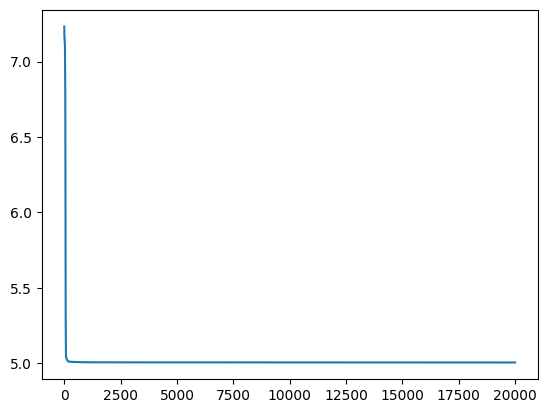

In [ ]:
plt.plot(cost_value)
plt.show()

Final cost: 3.195120946683941e-10
Training accuracy: 1.0


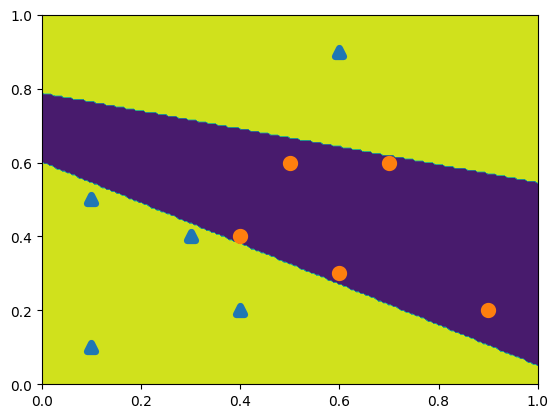

In [ ]:
import numpy as np
from numpy.random import normal
import matplotlib.pyplot as plt


x1 = np.array([0.1, 0.3, 0.1, 0.6, 0.4, 0.6, 0.5, 0.9, 0.4, 0.7])
x2 = np.array([0.1, 0.4, 0.5, 0.9, 0.2, 0.3, 0.6, 0.2, 0.4, 0.6])

y           = np.zeros((2, 10))
y[0:1, 0:5] = 1.0
y[1:,  5: ] = 1.0


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def activate(x, W, b):
    return sigmoid(W @ x + b)

def cost_function(W2,W3,W4,b2,b3,b4, x1, x2, y):
    n = len(x1)
    cost = 0.0
    x = np.zeros((2,1))
    for i in range(n):
        x[0,0], x[1,0] = x1[i], x2[i]
        a2 = activate(x,  W2, b2)
        a3 = activate(a2, W3, b3)
        a4 = activate(a3, W4, b4)
        e  = (a4.ravel() - y[:,i])
        cost += np.dot(e, e)  # ||e||^2
    return cost

def fullbatch_grads(W2,W3,W4,b2,b3,b4, x1, x2, y):
    """Gradients of the full-batch cost wrt all params (sums over samples)."""
    gW2 = np.zeros_like(W2); gW3 = np.zeros_like(W3); gW4 = np.zeros_like(W4)
    gb2 = np.zeros_like(b2); gb3 = np.zeros_like(b3); gb4 = np.zeros_like(b4)

    x = np.zeros((2,1))
    for i in range(len(x1)):
        x[0,0], x[1,0] = x1[i], x2[i]
        yi = y[:, i:i+1]  # (2,1)

        # forward
        z2 = W2 @ x  + b2; a2 = sigmoid(z2)
        z3 = W3 @ a2 + b3; a3 = sigmoid(z3)
        z4 = W4 @ a3 + b4; a4 = sigmoid(z4)

        # backward (cost = sum ||a4 - y||^2; d/d a4 = 2*(a4 - y))
        dC_da4 = 2.0 * (a4 - yi)                     # (2,1)
        delta4  = dC_da4 * a4 * (1 - a4)             # (2,1)
        delta3  = (W4.T @ delta4) * a3 * (1 - a3)    # (3,1)
        delta2  = (W3.T @ delta3) * a2 * (1 - a2)    # (2,1)

        gW4 += delta4 @ a3.T
        gW3 += delta3 @ a2.T
        gW2 += delta2 @ x.T
        gb4 += delta4
        gb3 += delta3
        gb2 += delta2

    return gW2,gW3,gW4,gb2,gb3,gb4


def pack(W2,W3,W4,b2,b3,b4):
    return np.concatenate([
        W2.ravel(), W3.ravel(), W4.ravel(),
        b2.ravel(), b3.ravel(), b4.ravel()
    ])

def unpack(theta):
    p = 0
    W2 = theta[p:p+4].reshape(2,2); p += 4
    W3 = theta[p:p+6].reshape(3,2); p += 6
    W4 = theta[p:p+6].reshape(2,3); p += 6
    b2 = theta[p:p+2].reshape(2,1); p += 2
    b3 = theta[p:p+3].reshape(3,1); p += 3
    b4 = theta[p:p+2].reshape(2,1); p += 2
    return W2,W3,W4,b2,b3,b4

def grad_vec(theta, x1, x2, y):
    W2,W3,W4,b2,b3,b4 = unpack(theta)
    gW2,gW3,gW4,gb2,gb3,gb4 = fullbatch_grads(W2,W3,W4,b2,b3,b4, x1, x2, y)
    return pack(gW2,gW3,gW4,gb2,gb3,gb4)

def cost_from_theta(theta, x1, x2, y):
    return cost_function(*unpack(theta), x1, x2, y)


def armijo_line_search(theta, p, g, J0, x1, x2, y, t0=1.0, beta=0.5, c=1e-4, t_min=1e-10):
    t = t0
    gTp = float(g @ p)
    while t >= t_min:
        J_new = cost_from_theta(theta + t*p, x1, x2, y)
        if J_new <= J0 + c * t * gTp:
            return t, J_new
        t *= beta
    return 0.0, J0


W2,W3,W4 = normal(size=(2,2)), normal(size=(3,2)), normal(size=(2,3))
b2,b3,b4 = normal(size=(2,1)), normal(size=(3,1)), normal(size=(2,1))
theta = pack(W2,W3,W4,b2,b3,b4)


max_iters = 50000
n = theta.size
H = np.eye(n)
cost_trace = []

for k in range(max_iters):
    J  = cost_from_theta(theta, x1, x2, y)
    g  = grad_vec(theta, x1, x2, y)
    p  = - H @ g


    t, J_new = armijo_line_search(theta, p, g, J, x1, x2, y, t0=1.0, beta=0.6, c=1e-4)
    s = t * p
    if t == 0.0 or np.linalg.norm(s) < 1e-12:

        cost_trace.append(J)
        break

    theta_new = theta + s
    g_new = grad_vec(theta_new, x1, x2, y)
    yk = g_new - g

    # BFGS update (with curvature check)
    ys = float(yk @ s)
    if ys <= 1e-12:
        # reset H if curvature is bad
        H = np.eye(n)
    else:
        rho = 1.0 / ys
        I = np.eye(n)
        V = I - rho * np.outer(s, yk)
        H = V @ H @ V.T + rho * np.outer(s, s)

    theta = theta_new
    cost_trace.append(J_new)


W2,W3,W4,b2,b3,b4 = unpack(theta)

def predict(xvec):
    a2 = sigmoid(W2 @ xvec + b2)
    a3 = sigmoid(W3 @ a2  + b3)
    a4 = sigmoid(W4 @ a3  + b4)
    return a4


def accuracy():
    correct = 0
    x = np.zeros((2,1))
    for i in range(len(x1)):
        x[0,0], x[1,0] = x1[i], x2[i]
        out = predict(x)
        pred0 = (out[0,0] >= out[1,0])
        true0 = (y[0,i] == 1.0)
        if pred0 == true0:
            correct += 1
    return correct / len(x1)

print("Final cost:", cost_trace[-1] if cost_trace else cost_from_theta(theta,x1,x2,y))
print("Training accuracy:", accuracy())




X, Y = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
X1Test = X.ravel(); X2Test = Y.ravel()
empty = np.zeros_like(X1Test)

xvec = np.zeros((2,1))
for i in range(X1Test.size):
    xvec[0,0], xvec[1,0] = X1Test[i], X2Test[i]
    out = predict(xvec)
    empty[i] = 1.0 if out[0,0] >= out[1,0] else 0.0

Z = empty.reshape(X.shape)
plt.figure()
plt.contourf(X, Y, Z)
plt.scatter(x1[0:5], x2[0:5], marker='^', lw=5)
plt.scatter(x1[5:],  x2[5:], marker='o', lw=5)
plt.show()


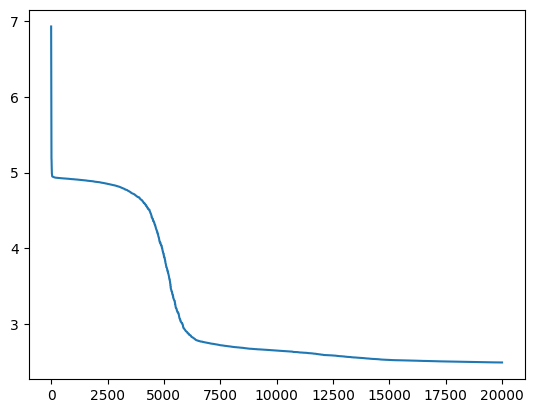

In [ ]:
plt.plot(cost_value)
plt.show()


=== Comparison (lower cost is better) ===
Method                                 Cost      Acc    Time(s)
SGD (η=0.75)                       0.000360    1.000      11.59
Differential Evolution             0.575030    1.000      15.56
Dual Annealing                     0.745319    1.000       5.13
Basin-Hopping + L-BFGS-B           0.290517    1.000      34.65

Best: SGD (η=0.75) | Cost=0.000360 | Acc=1.000 | Time=11.59s


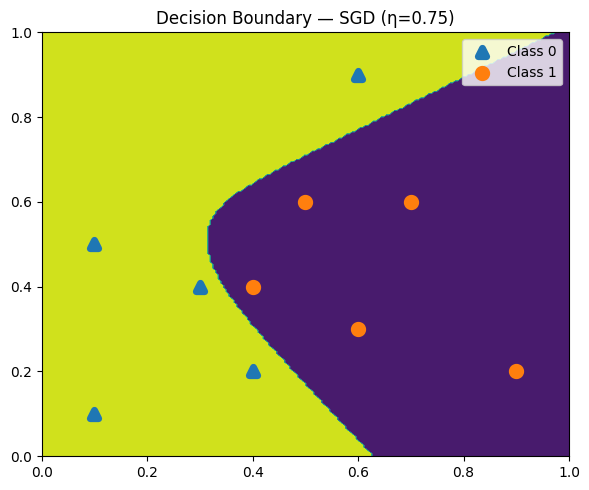

In [ ]:

import numpy as np
from numpy.random import normal, randint
import time
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, dual_annealing, basinhopping, minimize


x1 = np.array([0.1, 0.3, 0.1, 0.6, 0.4, 0.6, 0.5, 0.9, 0.4, 0.7])
x2 = np.array([0.1, 0.4, 0.5, 0.9, 0.2, 0.3, 0.6, 0.2, 0.4, 0.6])

y           = np.zeros((2, 10))
y[0:1, 0:5] = 1.0
y[1: , 5: ] = 1.0

rng = np.random.default_rng(0)


def sigmoid(z):
    return 1.0/(1.0+np.exp(-z))

def activate(x, W, b):
    return sigmoid(W @ x + b)


def pack(W2,W3,W4,b2,b3,b4):
    return np.concatenate([W2.ravel(), W3.ravel(), W4.ravel(),
                           b2.ravel(), b3.ravel(), b4.ravel()])

def unpack(theta):
    p=0
    W2 = theta[p:p+4].reshape(2,2); p+=4
    W3 = theta[p:p+6].reshape(3,2); p+=6
    W4 = theta[p:p+6].reshape(2,3); p+=6
    b2 = theta[p:p+2].reshape(2,1); p+=2
    b3 = theta[p:p+3].reshape(3,1); p+=3
    b4 = theta[p:p+2].reshape(2,1); p+=2
    return W2,W3,W4,b2,b3,b4

def init_params(scale=1.0, seed=None):
    rng = np.random.default_rng(seed)
    W2 = rng.normal(scale=scale, size=(2,2))
    W3 = rng.normal(scale=scale, size=(3,2))
    W4 = rng.normal(scale=scale, size=(2,3))
    b2 = rng.normal(scale=scale, size=(2,1))
    b3 = rng.normal(scale=scale, size=(3,1))
    b4 = rng.normal(scale=scale, size=(2,1))
    return pack(W2,W3,W4,b2,b3,b4)

def cost_from_theta(theta, x1, x2, y):
    W2,W3,W4,b2,b3,b4 = unpack(theta)
    n = len(x1)
    cost = 0.0
    x = np.zeros((2,1))
    for i in range(n):
        x[0,0], x[1,0] = x1[i], x2[i]
        a2 = sigmoid(W2 @ x + b2)
        a3 = sigmoid(W3 @ a2 + b3)
        a4 = sigmoid(W4 @ a3 + b4)
        e  = (a4.ravel() - y[:,i])
        cost += np.dot(e, e)
    return cost

def accuracy_from_theta(theta, x1, x2, y):
    W2,W3,W4,b2,b3,b4 = unpack(theta)
    correct = 0
    x = np.zeros((2,1))
    for i in range(len(x1)):
        x[0,0], x[1,0] = x1[i], x2[i]
        a2 = sigmoid(W2 @ x + b2)
        a3 = sigmoid(W3 @ a2 + b3)
        a4 = sigmoid(W4 @ a3 + b4)
        pred0 = (a4[0,0] >= a4[1,0])
        true0 = (y[0,i] == 1.0)
        correct += int(pred0 == true0)
    return correct/len(x1)


def train_sgd_fixed_eta(theta0, eta=0.75, Niter=100000, seed=0):
    rng = np.random.default_rng(seed)
    theta = theta0.copy()
    # unpack once for speed
    W2,W3,W4,b2,b3,b4 = unpack(theta)
    xvec = np.zeros((2,1)); yvec = np.zeros((2,1))
    t0 = time.time()
    for counter in range(Niter):
        k = rng.integers(0,10)
        xvec[0,0], xvec[1,0] = x1[k], x2[k]
        yvec[:,0] = y[:,k]
        # forward
        a2 = sigmoid(W2 @ xvec + b2)
        a3 = sigmoid(W3 @ a2   + b3)
        a4 = sigmoid(W4 @ a3   + b4)
        # backward
        delta4 = (2.0*(a4 - yvec)) * a4*(1 - a4)
        delta3 = (W4.T @ delta4) * a3*(1 - a3)
        delta2 = (W3.T @ delta3) * a2*(1 - a2)
        # updates
        W2 -= eta * (delta2 @ xvec.T)
        W3 -= eta * (delta3 @ a2.T)
        W4 -= eta * (delta4 @ a3.T)
        b2 -= eta * delta2
        b3 -= eta * delta3
        b4 -= eta * delta4
    elapsed = time.time()-t0
    theta = pack(W2,W3,W4,b2,b3,b4)
    J = cost_from_theta(theta, x1, x2, y)
    acc = accuracy_from_theta(theta, x1, x2, y)
    return theta, J, acc, elapsed


bounds = [(-5.0, 5.0)]*23

def run_differential_evolution(seed=0, maxiter=300, popsize=15, tol=1e-6):
    t0 = time.time()
    res = differential_evolution(
        func=lambda th: cost_from_theta(th, x1, x2, y),
        bounds=bounds,
        maxiter=maxiter,
        popsize=popsize,
        tol=tol,
        mutation=(0.5, 1.0),
        recombination=0.7,
        polish=True,
        seed=seed,
        updating='deferred',
        workers=1
    )
    elapsed = time.time()-t0
    theta = res.x
    J = res.fun
    acc = accuracy_from_theta(theta, x1, x2, y)
    return theta, J, acc, elapsed, res

def run_dual_annealing(seed=0, maxiter=600):
    t0 = time.time()
    res = dual_annealing(
        func=lambda th: cost_from_theta(th, x1, x2, y),
        bounds=bounds,
        maxiter=maxiter,
        seed=seed,
        initial_temp=5230.0,
        visit=2.62,
        accept=-5.0
    )
    elapsed = time.time()-t0
    theta = res.x
    J = res.fun
    acc = accuracy_from_theta(theta, x1, x2, y)
    return theta, J, acc, elapsed, res

def run_basinhopping(seed=0, niter=60, stepsize=0.5):
    # Basin-hopping needs an initial point; start from small random theta
    theta0 = init_params(scale=0.5, seed=seed)
    # Use an L-BFGS-B local step (bounded)
    def local_minimize(th):
        return minimize(lambda z: cost_from_theta(z, x1, x2, y),
                        th, method='L-BFGS-B', bounds=bounds)
    t0 = time.time()
    res = basinhopping(
        func=lambda th: cost_from_theta(th, x1, x2, y),
        x0=theta0,
        niter=niter,
        T=1.0,
        stepsize=stepsize,
        minimizer_kwargs={'method':'L-BFGS-B', 'bounds':bounds},
        seed=seed,
        disp=False
    )
    elapsed = time.time()-t0
    theta = res.x
    J = cost_from_theta(theta, x1, x2, y)
    acc = accuracy_from_theta(theta, x1, x2, y)
    return theta, J, acc, elapsed, res


results = []

# 1) SGD fixed-eta baseline (original method)
theta0 = init_params(scale=1.0, seed=42)
theta_sgd, J_sgd, acc_sgd, t_sgd = train_sgd_fixed_eta(theta0, eta=0.75, Niter=100000, seed=0)
results.append(("SGD (η=0.75)", J_sgd, acc_sgd, t_sgd, theta_sgd))

# 2) Differential Evolution (global)
theta_de, J_de, acc_de, t_de, _ = run_differential_evolution(seed=0, maxiter=200, popsize=12)
results.append(("Differential Evolution", J_de, acc_de, t_de, theta_de))

# 3) Dual Annealing (global)
theta_da, J_da, acc_da, t_da, _ = run_dual_annealing(seed=0, maxiter=300)
results.append(("Dual Annealing", J_da, acc_da, t_da, theta_da))

# 4) Basin-Hopping (global)
theta_bh, J_bh, acc_bh, t_bh, _ = run_basinhopping(seed=0, niter=50, stepsize=0.5)
results.append(("Basin-Hopping + L-BFGS-B", J_bh, acc_bh, t_bh, theta_bh))

print("\n=== Comparison ===")
print(f"{'Method':30} {'Cost':>12} {'Acc':>8} {'Time(s)':>10}")
for name, J, acc, tt, _ in results:
    print(f"{name:30} {J:12.6f} {acc:8.3f} {tt:10.2f}")


best_name, best_J, best_acc, best_t, best_theta = sorted(results, key=lambda r: r[1])[0]
print(f"\nBest: {best_name} | Cost={best_J:.6f} | Acc={best_acc:.3f} | Time={best_t:.2f}s")

W2,W3,W4,b2,b3,b4 = unpack(best_theta)

def predict_grid(xv):
    a2 = sigmoid(W2 @ xv + b2)
    a3 = sigmoid(W3 @ a2 + b3)
    a4 = sigmoid(W4 @ a3 + b4)
    return a4

X, Y = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
X1Test = X.ravel(); X2Test = Y.ravel()
empty  = np.zeros_like(X1Test)
xv = np.zeros((2,1))
for i in range(X1Test.size):
    xv[0,0], xv[1,0] = X1Test[i], X2Test[i]
    out = predict_grid(xv)
    empty[i] = 1.0 if out[0,0] >= out[1,0] else 0.0
Z = empty.reshape(X.shape)

plt.figure(figsize=(6,5))
plt.contourf(X, Y, Z)
plt.scatter(x1[0:5], x2[0:5], marker='^', lw=5, label='Class 0')
plt.scatter(x1[5:],  x2[5:], marker='o', lw=5, label='Class 1')
plt.title(f"Decision Boundary — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()



=== Optimizer Comparison (Breast Cancer, loss = SSE) ===
Method                            Time(s) |   TrainL     ValL    TestL |  TrainA    ValA   TestA
SGD (eta=0.05, sse)                  1.40 |   0.0291   0.0250   0.0392 |   0.979   0.974   0.947
SGD + Armijo LS (sse)                1.24 |   0.0134   0.0140   0.0299 |   0.988   0.974   0.974
BFGS + Armijo LS (sse)              12.32 |   0.0040   0.0129   0.0405 |   0.997   0.982   0.939
Differential Evolution (sse)       233.94 |   0.0337   0.0323   0.0458 |   0.971   0.956   0.965
Dual Annealing (sse)               123.66 |   0.0044   0.0105   0.0397 |   0.997   0.974   0.930
Basin-Hopping + L-BFGS-B (sse)     475.20 |   0.0041   0.0122   0.0406 |   0.997   0.982   0.939


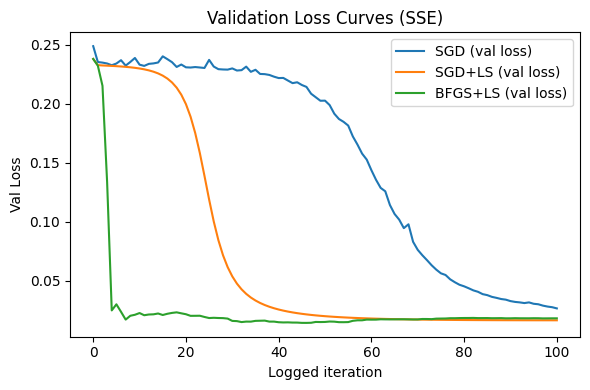

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.optimize import differential_evolution, dual_annealing, basinhopping, minimize


LOSS = "sse"
HIDDEN1, HIDDEN2 = 8, 8
SEED = 42


ds = load_breast_cancer()
X = ds.data.astype(np.float64)
y = ds.target.astype(np.int64)


X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, random_state=SEED, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)


scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)
X_val = scaler.transform(X_val)
X_te  = scaler.transform(X_te)

n_in  = X_tr.shape[1]
n_h1, n_h2 = HIDDEN1, HIDDEN2
n_out = 1


def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))
def dsigmoid(a): return a * (1.0 - a)


def shapes():
    return {
        "W1": (n_h1, n_in),
        "b1": (n_h1, 1),
        "W2": (n_h2, n_h1),
        "b2": (n_h2, 1),
        "W3": (n_out, n_h2),
        "b3": (n_out, 1),
    }

def init_params(scale=0.1, seed=None):
    rng = default_rng(seed)
    W1 = rng.normal(0, scale, size=(n_h1, n_in))
    b1 = rng.normal(0, scale, size=(n_h1, 1))
    W2 = rng.normal(0, scale, size=(n_h2, n_h1))
    b2 = rng.normal(0, scale, size=(n_h2, 1))
    W3 = rng.normal(0, scale, size=(n_out, n_h2))
    b3 = rng.normal(0, scale, size=(n_out, 1))
    return pack(W1, b1, W2, b2, W3, b3)

def pack(W1,b1,W2,b2,W3,b3):
    return np.concatenate([W1.ravel(), b1.ravel(), W2.ravel(), b2.ravel(), W3.ravel(), b3.ravel()])

def unpack(theta):
    s = shapes()
    p = 0
    W1 = theta[p:p + s["W1"][0]*s["W1"][1]].reshape(s["W1"]); p += s["W1"][0]*s["W1"][1]
    b1 = theta[p:p + s["b1"][0]*s["b1"][1]].reshape(s["b1"]); p += s["b1"][0]*s["b1"][1]
    W2 = theta[p:p + s["W2"][0]*s["W2"][1]].reshape(s["W2"]); p += s["W2"][0]*s["W2"][1]
    b2 = theta[p:p + s["b2"][0]*s["b2"][1]].reshape(s["b2"]); p += s["b2"][0]*s["b2"][1]
    W3 = theta[p:p + s["W3"][0]*s["W3"][1]].reshape(s["W3"]); p += s["W3"][0]*s["W3"][1]
    b3 = theta[p:p + s["b3"][0]*s["b3"][1]].reshape(s["b3"])
    return W1,b1,W2,b2,W3,b3

def forward_batch(W1,b1,W2,b2,W3,b3, X):  # X: (N, d)
    Z1 = X @ W1.T + b1.T
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2.T + b2.T
    A2 = sigmoid(Z2)
    Z3 = A2 @ W3.T + b3.T
    A3 = sigmoid(Z3)  # (N,1)
    return (A1,A2,A3), (Z1,Z2,Z3)

def predict_proba(theta, X):
    W1,b1,W2,b2,W3,b3 = unpack(theta)
    _,_,A3 = forward_batch(W1,b1,W2,b2,W3,b3, X)[0]
    return A3.ravel()  # (N,)

def accuracy(theta, X, y):
    p = predict_proba(theta, X)
    yhat = (p >= 0.5).astype(int)
    return (yhat == y).mean()


def loss_and_grad(theta, X, y, reg=0.0):
    W1,b1,W2,b2,W3,b3 = unpack(theta)
    (A1,A2,A3), (Z1,Z2,Z3) = forward_batch(W1,b1,W2,b2,W3,b3, X)
    N = X.shape[0]
    y = y.reshape(-1,1)

    if LOSS == "bce":
        eps = 1e-12
        J = -np.mean(y*np.log(A3+eps) + (1-y)*np.log(1-A3+eps))
        dZ3 = (A3 - y) / N
    elif LOSS == "sse":
        J = np.mean((A3 - y)**2)
        dZ3 = 2*(A3 - y) * dsigmoid(A3) / N
    else:
        raise ValueError("LOSS must be 'bce' or 'sse'")

    J += 0.5*reg*(np.sum(W1*W1)+np.sum(W2*W2)+np.sum(W3*W3))

    dW3 = dZ3.T @ A2 + reg*W3
    db3 = dZ3.sum(axis=0, keepdims=True)
    dA2 = dZ3 @ W3
    dZ2 = dA2 * dsigmoid(A2)
    dW2 = dZ2.T @ A1 + reg*W2
    db2 = dZ2.sum(axis=0, keepdims=True)
    dA1 = dZ2 @ W2
    dZ1 = dA1 * dsigmoid(A1)
    dW1 = dZ1.T @ X + reg*W1
    db1 = dZ1.sum(axis=0, keepdims=True)

    grad = pack(dW1, db1.T, dW2, db2.T, dW3, db3.T)
    return float(J), grad

def loss_only(theta, X, y, reg=0.0):
    J,_ = loss_and_grad(theta, X, y, reg=reg)
    return J


def armijo_line_search(theta, p, g, X, y, reg=0.0, t0=1.0, beta=0.5, c=1e-4):
    J0 = loss_only(theta, X, y, reg)
    gTp = g.dot(p)
    t = t0
    while t > 1e-12:
        J_new = loss_only(theta + t*p, X, y, reg)
        if J_new <= J0 + c * t * gTp:
            return t, J_new
        t *= beta
    return 0.0, J0


def run_sgd_fixed_eta(theta0, X, y, Xv, yv, reg=0.0, eta=0.05, iters=2000, seed=SEED):
    rng = default_rng(seed)
    theta = theta0.copy()
    N = X.shape[0]
    trace = []
    t0 = time.time()
    for k in range(iters):
        i = rng.integers(0, N)
        Xi = X[i:i+1]; yi = y[i:i+1]
        J, g = loss_and_grad(theta, Xi, yi, reg=reg)  # stochastic gradient
        theta -= eta * g
        if (k % max(1,iters//100)) == 0 or k==iters-1:
            trace.append(loss_only(theta, Xv, yv, reg))
    elapsed = time.time()-t0
    return theta, np.array(trace), elapsed

def run_sgd_linesearch(theta0, X, y, Xv, yv, reg=0.0, iters=400, t0_ls=1.0):

    theta = theta0.copy()
    trace = []
    t0 = time.time()
    for k in range(iters):
        J, g = loss_and_grad(theta, X, y, reg=reg)
        p = -g
        t, _ = armijo_line_search(theta, p, g, X, y, reg=reg, t0=t0_ls)
        if t == 0.0:
            t = 1e-3
        theta = theta + t * p
        if (k % max(1,iters//100)) == 0 or k==iters-1:
            trace.append(loss_only(theta, Xv, yv, reg))
    elapsed = time.time()-t0
    return theta, np.array(trace), elapsed

def run_bfgs_linesearch(theta0, X, y, Xv, yv, reg=0.0, iters=300):
    theta = theta0.copy()
    n = theta.size
    H = np.eye(n)
    trace = []
    t0 = time.time()
    for k in range(iters):
        J, g = loss_and_grad(theta, X, y, reg=reg)
        p = - H @ g
        t, _ = armijo_line_search(theta, p, g, X, y, reg=reg, t0=1.0, beta=0.6)
        if t == 0.0:
            t = 1e-3
        s = t * p
        theta_new = theta + s
        J_new, g_new = loss_and_grad(theta_new, X, y, reg=reg)
        yk = g_new - g
        ys = yk.dot(s)
        if ys > 1e-12:
            rho = 1.0 / ys
            I = np.eye(n)
            V = I - rho * np.outer(s, yk)
            H = V @ H @ V.T + rho * np.outer(s, s)
        else:
            H = np.eye(n)
        theta = theta_new
        if (k % max(1,iters//100)) == 0 or k==iters-1:
            trace.append(loss_only(theta, Xv, yv, reg))
    elapsed = time.time()-t0
    return theta, np.array(trace), elapsed


def bounds_all(theta_dim, lo=-2.0, hi=2.0):
    return [(lo, hi)] * theta_dim

def run_de(X, y, Xv, yv, reg=0.0, maxiter=150, popsize=10, seed=SEED):
    bnds = bounds_all(init_params().size)
    t0 = time.time()
    res = differential_evolution(
        func=lambda th: loss_only(th, X, y, reg),
        bounds=bnds, maxiter=maxiter, popsize=popsize,
        recombination=0.7, mutation=(0.5,1.0),
        seed=seed, polish=True, updating='deferred', workers=1
    )
    elapsed = time.time()-t0
    theta = res.x
    return theta, np.array([]), elapsed

def run_dual_annealing(X, y, Xv, yv, reg=0.0, maxiter=400, seed=SEED):
    bnds = bounds_all(init_params().size)
    t0 = time.time()
    res = dual_annealing(
        func=lambda th: loss_only(th, X, y, reg),
        bounds=bnds, maxiter=maxiter, seed=seed
    )
    elapsed = time.time()-t0
    theta = res.x
    return theta, np.array([]), elapsed

def run_basinhopping(X, y, Xv, yv, reg=0.0, niter=60, stepsize=0.4, seed=SEED):
    bnds = bounds_all(init_params().size)
    theta0 = init_params(scale=0.2, seed=seed)
    def local_minimize(th):
        return minimize(lambda z: loss_only(z, X, y, reg),
                        th, method='L-BFGS-B', bounds=bnds)
    t0 = time.time()
    res = basinhopping(
        func=lambda th: loss_only(th, X, y, reg),
        x0=theta0, niter=niter, T=1.0, stepsize=stepsize,
        minimizer_kwargs={'method':'L-BFGS-B','bounds':bnds},
        seed=seed, disp=False
    )
    elapsed = time.time()-t0
    theta = res.x
    return theta, np.array([]), elapsed


def evaluate(theta, name, elapsed):
    tr_loss = loss_only(theta, X_tr, y_tr)
    va_loss = loss_only(theta, X_val, y_val)
    te_loss = loss_only(theta, X_te,  y_te)
    tr_acc  = accuracy(theta, X_tr, y_tr)
    va_acc  = accuracy(theta, X_val, y_val)
    te_acc  = accuracy(theta, X_te,  y_te)
    return {
        "method": name, "time": elapsed,
        "train_loss": tr_loss, "val_loss": va_loss, "test_loss": te_loss,
        "train_acc": tr_acc,  "val_acc": va_acc,  "test_acc": te_acc,
        "theta": theta
    }

theta0 = init_params(scale=0.1, seed=SEED)

results = []

# SGD fixed-eta
theta, trace, t = run_sgd_fixed_eta(theta0, X_tr, y_tr, X_val, y_val, reg=1e-4, eta=0.05, iters=4000)
results.append(evaluate(theta, f"SGD (eta=0.05, {LOSS})", t))

# SGD + LS (full-batch)
theta, trace_ls, t = run_sgd_linesearch(theta0, X_tr, y_tr, X_val, y_val, reg=1e-4, iters=500)
results.append(evaluate(theta, f"SGD + Armijo LS ({LOSS})", t))

# BFGS + LS
theta, trace_bfgs, t = run_bfgs_linesearch(theta0, X_tr, y_tr, X_val, y_val, reg=1e-4, iters=400)
results.append(evaluate(theta, f"BFGS + Armijo LS ({LOSS})", t))

# Global methods
theta, _, t = run_de(X_tr, y_tr, X_val, y_val, reg=1e-4, maxiter=120, popsize=10)
results.append(evaluate(theta, f"Differential Evolution ({LOSS})", t))

theta, _, t = run_dual_annealing(X_tr, y_tr, X_val, y_val, reg=1e-4, maxiter=350)
results.append(evaluate(theta, f"Dual Annealing ({LOSS})", t))

theta, _, t = run_basinhopping(X_tr, y_tr, X_val, y_val, reg=1e-4, niter=60, stepsize=0.4)
results.append(evaluate(theta, f"Basin-Hopping + L-BFGS-B ({LOSS})", t))


print("\n=== Optimizer Comparison (Breast Cancer, loss = {}) ===".format(LOSS.upper()))
print(f"{'Method':32} {'Time(s)':>8} | {'TrainL':>8} {'ValL':>8} {'TestL':>8} | {'TrainA':>7} {'ValA':>7} {'TestA':>7}")
for r in results:
    print(f"{r['method'][:32]:32} {r['time']:8.2f} | {r['train_loss']:8.4f} {r['val_loss']:8.4f} {r['test_loss']:8.4f} | {r['train_acc']:7.3f} {r['val_acc']:7.3f} {r['test_acc']:7.3f}")


# Plot validation loss traces for gradient-based methods

plt.figure(figsize=(6,4))
if len(trace) > 0:     plt.plot(trace,      label="SGD (val loss)")
if len(trace_ls) > 0:  plt.plot(trace_ls,   label="SGD+LS (val loss)")
if len(trace_bfgs) > 0:plt.plot(trace_bfgs, label="BFGS+LS (val loss)")
plt.title(f"Validation Loss Curves ({LOSS.upper()})")
plt.xlabel("Logged iteration")
plt.ylabel("Val Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.optimize import differential_evolution, dual_annealing, basinhopping, minimize


LOSS = "sse"
HIDDEN1, HIDDEN2 = 8, 8
SEED = 42


ds = load_breast_cancer()
X = ds.data.astype(np.float64)
y = ds.target.astype(np.int64)


X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, random_state=SEED, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)


scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)
X_val = scaler.transform(X_val)
X_te  = scaler.transform(X_te)

n_in  = X_tr.shape[1]
n_h1, n_h2 = HIDDEN1, HIDDEN2
n_out = 1


def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))
def dsigmoid(a): return a * (1.0 - a)


def shapes():
    return {
        "W1": (n_h1, n_in),
        "b1": (n_h1, 1),
        "W2": (n_h2, n_h1),
        "b2": (n_h2, 1),
        "W3": (n_out, n_h2),
        "b3": (n_out, 1),
    }

def init_params(scale=0.1, seed=None):
    rng = default_rng(seed)
    W1 = rng.normal(0, scale, size=(n_h1, n_in))
    b1 = rng.normal(0, scale, size=(n_h1, 1))
    W2 = rng.normal(0, scale, size=(n_h2, n_h1))
    b2 = rng.normal(0, scale, size=(n_h2, 1))
    W3 = rng.normal(0, scale, size=(n_out, n_h2))
    b3 = rng.normal(0, scale, size=(n_out, 1))
    return pack(W1, b1, W2, b2, W3, b3)

def pack(W1,b1,W2,b2,W3,b3):
    return np.concatenate([W1.ravel(), b1.ravel(), W2.ravel(), b2.ravel(), W3.ravel(), b3.ravel()])

def unpack(theta):
    s = shapes()
    p = 0
    W1 = theta[p:p + s["W1"][0]*s["W1"][1]].reshape(s["W1"]); p += s["W1"][0]*s["W1"][1]
    b1 = theta[p:p + s["b1"][0]*s["b1"][1]].reshape(s["b1"]); p += s["b1"][0]*s["b1"][1]
    W2 = theta[p:p + s["W2"][0]*s["W2"][1]].reshape(s["W2"]); p += s["W2"][0]*s["W2"][1]
    b2 = theta[p:p + s["b2"][0]*s["b2"][1]].reshape(s["b2"]); p += s["b2"][0]*s["b2"][1]
    W3 = theta[p:p + s["W3"][0]*s["W3"][1]].reshape(s["W3"]); p += s["W3"][0]*s["W3"][1]
    b3 = theta[p:p + s["b3"][0]*s["b3"][1]].reshape(s["b3"])
    return W1,b1,W2,b2,W3,b3

def forward_batch(W1,b1,W2,b2,W3,b3, X):  # X: (N, d)
    Z1 = X @ W1.T + b1.T
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2.T + b2.T
    A2 = sigmoid(Z2)
    Z3 = A2 @ W3.T + b3.T
    A3 = sigmoid(Z3)  # (N,1)
    return (A1,A2,A3), (Z1,Z2,Z3)

def predict_proba(theta, X):
    W1,b1,W2,b2,W3,b3 = unpack(theta)
    _,_,A3 = forward_batch(W1,b1,W2,b2,W3,b3, X)[0]
    return A3.ravel()  # (N,)

def accuracy(theta, X, y):
    p = predict_proba(theta, X)
    yhat = (p >= 0.5).astype(int)
    return (yhat == y).mean()


def loss_and_grad(theta, X, y, reg=0.0):
    W1,b1,W2,b2,W3,b3 = unpack(theta)
    (A1,A2,A3), (Z1,Z2,Z3) = forward_batch(W1,b1,W2,b2,W3,b3, X)
    N = X.shape[0]
    y = y.reshape(-1,1)

    if LOSS == "bce":
        eps = 1e-12
        J = -np.mean(y*np.log(A3+eps) + (1-y)*np.log(1-A3+eps))
        dZ3 = (A3 - y) / N
    elif LOSS == "sse":
        J = np.mean((A3 - y)**2)
        dZ3 = 2*(A3 - y) * dsigmoid(A3) / N
    else:
        raise ValueError("LOSS must be 'bce' or 'sse'")

    J += 0.5*reg*(np.sum(W1*W1)+np.sum(W2*W2)+np.sum(W3*W3))

    dW3 = dZ3.T @ A2 + reg*W3
    db3 = dZ3.sum(axis=0, keepdims=True)
    dA2 = dZ3 @ W3
    dZ2 = dA2 * dsigmoid(A2)
    dW2 = dZ2.T @ A1 + reg*W2
    db2 = dZ2.sum(axis=0, keepdims=True)
    dA1 = dZ2 @ W2
    dZ1 = dA1 * dsigmoid(A1)
    dW1 = dZ1.T @ X + reg*W1
    db1 = dZ1.sum(axis=0, keepdims=True)

    grad = pack(dW1, db1.T, dW2, db2.T, dW3, db3.T)
    return float(J), grad

def loss_only(theta, X, y, reg=0.0):
    J,_ = loss_and_grad(theta, X, y, reg=reg)
    return J


def armijo_line_search(theta, p, g, X, y, reg=0.0, t0=1.0, beta=0.5, c=1e-4):
    J0 = loss_only(theta, X, y, reg)
    gTp = g.dot(p)
    t = t0
    while t > 1e-12:
        J_new = loss_only(theta + t*p, X, y, reg)
        if J_new <= J0 + c * t * gTp:
            return t, J_new
        t *= beta
    return 0.0, J0


def run_sgd_fixed_eta(theta0, X, y, Xv, yv, reg=0.0, eta=0.05, iters=2000, seed=SEED):
    rng = default_rng(seed)
    theta = theta0.copy()
    N = X.shape[0]
    trace = []
    t0 = time.time()
    for k in range(iters):
        i = rng.integers(0, N)
        Xi = X[i:i+1]; yi = y[i:i+1]
        J, g = loss_and_grad(theta, Xi, yi, reg=reg)  # stochastic gradient
        theta -= eta * g
        if (k % max(1,iters//100)) == 0 or k==iters-1:
            trace.append(loss_only(theta, Xv, yv, reg))
    elapsed = time.time()-t0
    return theta, np.array(trace), elapsed

def run_sgd_linesearch(theta0, X, y, Xv, yv, reg=0.0, iters=400, t0_ls=1.0):

    theta = theta0.copy()
    trace = []
    t0 = time.time()
    for k in range(iters):
        J, g = loss_and_grad(theta, X, y, reg=reg)
        p = -g
        t, _ = armijo_line_search(theta, p, g, X, y, reg=reg, t0=t0_ls)
        if t == 0.0:
            t = 1e-3
        theta = theta + t * p
        if (k % max(1,iters//100)) == 0 or k==iters-1:
            trace.append(loss_only(theta, Xv, yv, reg))
    elapsed = time.time()-t0
    return theta, np.array(trace), elapsed

def run_bfgs_linesearch(theta0, X, y, Xv, yv, reg=0.0, iters=300):
    theta = theta0.copy()
    n = theta.size
    H = np.eye(n)
    trace = []
    t0 = time.time()
    for k in range(iters):
        J, g = loss_and_grad(theta, X, y, reg=reg)
        p = - H @ g
        t, _ = armijo_line_search(theta, p, g, X, y, reg=reg, t0=1.0, beta=0.6)
        if t == 0.0:
            t = 1e-3
        s = t * p
        theta_new = theta + s
        J_new, g_new = loss_and_grad(theta_new, X, y, reg=reg)
        yk = g_new - g
        ys = yk.dot(s)
        if ys > 1e-12:
            rho = 1.0 / ys
            I = np.eye(n)
            V = I - rho * np.outer(s, yk)
            H = V @ H @ V.T + rho * np.outer(s, s)
        else:
            H = np.eye(n)
        theta = theta_new
        if (k % max(1,iters//100)) == 0 or k==iters-1:
            trace.append(loss_only(theta, Xv, yv, reg))
    elapsed = time.time()-t0
    return theta, np.array(trace), elapsed


def bounds_all(theta_dim, lo=-2.0, hi=2.0):
    return [(lo, hi)] * theta_dim

def run_de(X, y, Xv, yv, reg=0.0, maxiter=150, popsize=10, seed=SEED):
    bnds = bounds_all(init_params().size)
    t0 = time.time()
    res = differential_evolution(
        func=lambda th: loss_only(th, X, y, reg),
        bounds=bnds, maxiter=maxiter, popsize=popsize,
        recombination=0.7, mutation=(0.5,1.0),
        seed=seed, polish=True, updating='deferred', workers=1
    )
    elapsed = time.time()-t0
    theta = res.x
    return theta, np.array([]), elapsed

def run_dual_annealing(X, y, Xv, yv, reg=0.0, maxiter=400, seed=SEED):
    bnds = bounds_all(init_params().size)
    t0 = time.time()
    res = dual_annealing(
        func=lambda th: loss_only(th, X, y, reg),
        bounds=bnds, maxiter=maxiter, seed=seed
    )
    elapsed = time.time()-t0
    theta = res.x
    return theta, np.array([]), elapsed

def run_basinhopping(X, y, Xv, yv, reg=0.0, niter=60, stepsize=0.4, seed=SEED):
    bnds = bounds_all(init_params().size)
    theta0 = init_params(scale=0.2, seed=seed)
    def local_minimize(th):
        return minimize(lambda z: loss_only(z, X, y, reg),
                        th, method='L-BFGS-B', bounds=bnds)
    t0 = time.time()
    res = basinhopping(
        func=lambda th: loss_only(th, X, y, reg),
        x0=theta0, niter=niter, T=1.0, stepsize=stepsize,
        minimizer_kwargs={'method':'L-BFGS-B','bounds':bnds},
        seed=seed, disp=False
    )
    elapsed = time.time()-t0
    theta = res.x
    return theta, np.array([]), elapsed


def evaluate(theta, name, elapsed):
    tr_loss = loss_only(theta, X_tr, y_tr)
    va_loss = loss_only(theta, X_val, y_val)
    te_loss = loss_only(theta, X_te,  y_te)
    tr_acc  = accuracy(theta, X_tr, y_tr)
    va_acc  = accuracy(theta, X_val, y_val)
    te_acc  = accuracy(theta, X_te,  y_te)
    return {
        "method": name, "time": elapsed,
        "train_loss": tr_loss, "val_loss": va_loss, "test_loss": te_loss,
        "train_acc": tr_acc,  "val_acc": va_acc,  "test_acc": te_acc,
        "theta": theta
    }

theta0 = init_params(scale=0.1, seed=SEED)

results2 = []
theta, trace, t = run_sgd_fixed_eta(theta0, X_tr, y_tr, X_val, y_val, reg=1e-4, eta=0.75, iters=4000)
results2.append(evaluate(theta, f"SGD (eta=0.75, {LOSS})", t))
print(results2)

[{'method': 'SGD (eta=0.75, sse)', 'time': 1.414740800857544, 'train_loss': 0.016352250100070728, 'val_loss': 0.0171846910654913, 'test_loss': 0.03335792346754141, 'train_acc': np.float64(0.9794721407624634), 'val_acc': np.float64(0.9736842105263158), 'test_acc': np.float64(0.9649122807017544), 'theta': array([-4.51567802e-03, -4.53585731e-02,  2.87189731e-02,  5.61091654e-02,
       -1.21354846e-01, -1.22218872e-01,  7.87931909e-03, -3.61451729e-02,
       -5.93210151e-02, -6.36441803e-02,  7.21352894e-02,  1.53484742e-02,
       -8.72956234e-03,  8.90144229e-02,  1.41696015e-01, -7.69982545e-02,
        2.45775331e-02, -9.76800441e-02,  3.74372288e-02,  1.59224248e-02,
       -2.72371627e-02, -5.62896564e-02,  7.65960205e-02, -1.04890049e-02,
        4.10901479e-03, -3.64212472e-02,  2.98720398e-02,  1.19638728e-03,
       -9.38502545e-03,  5.37511499e-02,  9.02066316e-01,  4.42143779e-01,
        6.67199142e-01,  6.79966518e-01,  1.23034276e-01,  1.56797704e-01,
        3.47864741e-